In [9]:
# ============================================================
# IMPORTS
# ============================================================
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [10]:
# ============================================================
# PATHS
# ============================================================
TRAIN_DIR = "/kaggle/input/brisc2025/brisc2025/classification_task/train"
WORK_DIR = "/kaggle/working/results"
os.makedirs(WORK_DIR, exist_ok=True)

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Train directory not found: {TRAIN_DIR}")

# ============================================================
# DATA GENERATORS
# ============================================================
batch_size = 16
target_size = (224, 224)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.12,
    zoom_range=0.20,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.20
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="sparse",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=target_size,
    batch_size=batch_size,
    class_mode="sparse",
    subset="validation",
    shuffle=False
)

num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())
print("Classes:", train_generator.class_indices)

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


In [11]:
# ============================================================
# MODEL: DENSENET121
# ============================================================
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze first ~70% layers
for layer in base_model.layers[:300]:
    layer.trainable = False
for layer in base_model.layers[300:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation="relu",
          kernel_regularizer=regularizers.l2(8e-4))(x)
x = Dropout(0.45)(x)

x = Dense(128, activation="relu",
          kernel_regularizer=regularizers.l2(8e-4))(x)
x = Dropout(0.35)(x)

output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

# ============================================================
# COMPILE
# ============================================================
model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,337,412 (27.99 MB)

 Trainable params: 3,187,268 (12.16 MB)

 Non-trainable params: 4,150,144 (15.83 MB)

In [12]:
# ============================================================
# CALLBACKS
# ============================================================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

# ============================================================
# TRAINING
# ============================================================
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 620s 2s/step - accuracy: 0.7142 - loss: 1.2122 - val_accuracy: 0.8347 - val_loss: 0.8355 - learning_rate: 3.0000e-04
Epoch 2/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 552s 2s/step - accuracy: 0.9066 - loss: 0.6247 - val_accuracy: 0.8968 - val_loss: 0.6429 - learning_rate: 3.0000e-04
Epoch 3/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 557s 2s/step - accuracy: 0.9257 - loss: 0.5648 - val_accuracy: 0.9269 - val_loss: 0.5267 - learning_rate: 3.0000e-04
Epoch 4/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 563s 2s/step - accuracy: 0.9465 - loss: 0.4806 - val_accuracy: 0.9248 - val_loss: 0.6098 - learning_rate: 3.0000e-04
Epoch 5/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.9541 - loss: 0.4476 - val_accuracy: 0.8727 - val_loss: 0.8084 - learning_rate: 3.0000e-04
Epoch 6/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 549s 2s/step - accuracy: 0.9561 - loss: 0.4147 - val_accuracy: 0.9579 - val_loss: 0.4398 - learning_rate: 1.5000e-04
Epoch 7/100
251/251 ━━━━━━━━━━━━━━━━━━━━ 559s 2s/ste

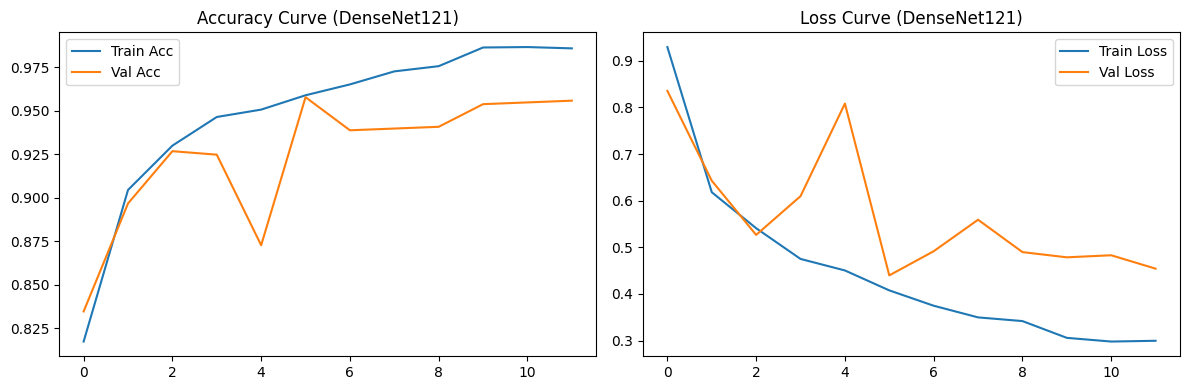

In [13]:
# ============================================================
# TRAINING CURVES
# ============================================================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy Curve (DenseNet121)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss Curve (DenseNet121)")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# FINAL EVALUATION
# ============================================================
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

# ============================================================
# PREDICTIONS & METRICS
# ============================================================
val_generator.reset()
pred_probs = model.predict(val_generator, verbose=0)
y_pred = np.argmax(pred_probs, axis=1)
y_true = val_generator.classes

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro")
rec  = recall_score(y_true, y_pred, average="macro")
f1   = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy : {acc*100:.2f}")
print(f"Precision: {prec*100:.2f}")
print(f"Recall   : {rec*100:.2f}")
print(f"F1-score : {f1*100:.2f}")


Validation Loss: 0.4294
Validation Accuracy: 95.79%

Classification Report:

              precision    recall  f1-score   support

      glioma       0.97      0.98      0.98       229
  meningioma       0.95      0.90      0.93       265
    no_tumor       0.94      0.97      0.95       213
   pituitary       0.96      0.97      0.96       291

    accuracy                           0.95       998
   macro avg       0.95      0.96      0.96       998
weighted avg       0.95      0.95      0.95       998

Accuracy : 95.49
Precision: 95.47
Recall   : 95.61
F1-score : 95.51


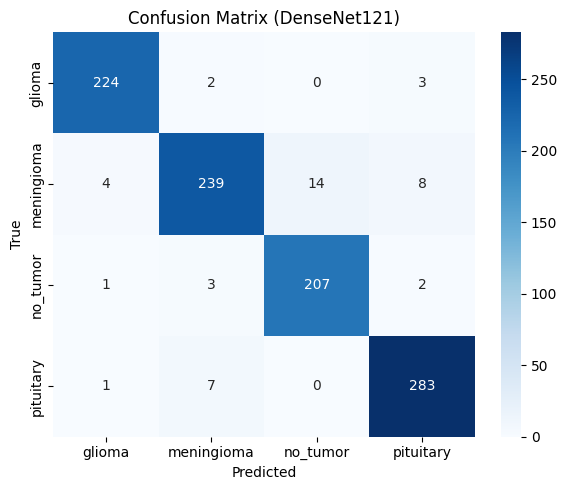

In [15]:
# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (DenseNet121)")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# SAVE RESULTS
# ============================================================
# Predictions
pred_path = os.path.join(WORK_DIR, "predictions.csv")
np.savetxt(
    pred_path,
    np.column_stack([y_true, y_pred]),
    delimiter=",",
    header="true_label,predicted_label",
    comments="",
    fmt="%d"
)

# Metrics
metrics_path = os.path.join(WORK_DIR, "metrics.csv")
with open(metrics_path, "w") as f:
    f.write("metric,value\n")
    f.write(f"accuracy,{acc:.6f}\n")
    f.write(f"precision_macro,{prec:.6f}\n")
    f.write(f"recall_macro,{rec:.6f}\n")
    f.write(f"f1_macro,{f1:.6f}\n")

# Confusion Matrix
cm_path = os.path.join(WORK_DIR, "confusion_matrix.npy")
np.save(cm_path, cm)

# ============================================================
# ZIP RESULTS
# ============================================================
zip_path = "/kaggle/working/densenet121_results.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(pred_path, "predictions.csv")
    zipf.write(metrics_path, "metrics.csv")
    zipf.write(cm_path, "confusion_matrix.npy")

print(f"\n✅ Results ZIP saved at: {zip_path}")


✅ Results ZIP saved at: /kaggle/working/densenet121_results.zip
